### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P101 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

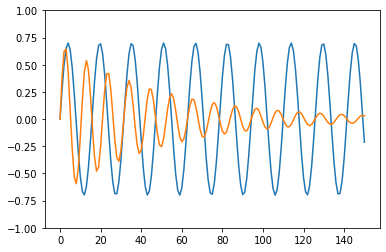

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 4

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

101

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect X local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.0002820360233344303   3.7066116333007812 sec       
199: 0.00023573866694643752   5.6953818798065186 sec      
299: 0.0002168921244779177   7.549314737319946 sec        
399: 0.00020253086590066798   9.467950582504272 sec      
499: 0.0001900080402172739   11.414385318756104 sec       
599: 0.00017949499448129333   13.654885053634644 sec      
699: 0.000364838467621071   15.809142351150513 sec        
799: 0.00023189521210762514   17.978525400161743 sec      
899: 0.00019261429630991069   20.391006469726562 sec      
learning rate: 0.1
999: 0.00022394356860560308   22.762165069580078 sec      
1099: 0.0001880345540962385   25.31851053237915 sec        
1199: 0.00017029437189465855   27.880998134613037 sec      
1299: 0.00015784881274525313   30.34770894050598 sec       
1399: 0.000145315404619485   32.88823318481445 sec         
1499: 0.0001319903964251492   35.4695041179657 sec         
1599: 0.00011940975153970735   37.89609622955322 sec       
1699: 0.000108

26399: 0.00014761297355351592   427.59706950187683 sec      
learning rate: 0.1
26499: 0.00017398519021922038   429.061514377594 sec        
26599: 0.00014822330388413282   430.4649271965027 sec       
learning rate: 0.05
26699: 0.00017322113496976002   431.896279335022 sec        
learning rate: 0.025
26799: 0.00010123120458919912   433.33822107315063 sec      
26899: 0.0001057644879152804   434.8102226257324 sec        
26999: 9.456411106140242e-05   436.30501222610474 sec       
27099: 0.0001007648586669252   437.6959619522095 sec        
27199: 9.08811278603547e-05   439.14420676231384 sec        
27299: 9.198148722024069e-05   440.55232787132263 sec       
27399: 8.227067423387271e-05   442.09873843193054 sec      
27499: 8.281079435333809e-05   443.5019166469574 sec        
27599: 8.320233075025316e-05   444.83625984191895 sec       
27699: 9.031397061393646e-05   446.1840867996216 sec        
learning rate: 0.0125
27799: 7.865903909161916e-05   447.6027982234955 sec        
2789

52499: 4.8287494301676e-05   820.4116938114166 sec         
learning rate: 0.2
52599: 0.00036536703338400456   822.0388815402985 sec      
52699: 0.0005011405973063809   823.6613664627075 sec       
52799: 0.00014494200173722913   825.1214914321899 sec      
52899: 0.00015362507213650159   826.7657222747803 sec      
52999: 0.0006433419202010009   828.3915464878082 sec       
53099: 0.00030280613507434963   829.9522194862366 sec      
learning rate: 0.1
53199: 0.0002860392989261184   831.6151974201202 sec       
learning rate: 0.05
53299: 0.00012767911142399658   833.2235901355743 sec      
53399: 0.00017669497309191838   834.851701259613 sec       
53499: 0.00013492817851077054   836.4469034671783 sec      
53599: 0.000124396486213169   838.1105163097382 sec        
53699: 0.00011346505032170631   839.6976208686829 sec      
53799: 9.527090213846219e-05   841.335305929184 sec        
53899: 0.0001220691435789471   842.9728708267212 sec       
53999: 8.785500828489431e-05   844.5608735

78799: 0.0002153229253007988   1292.798968076706 sec        
78899: 0.00019262207921862722   1294.5146930217743 sec      
learning rate: 0.1
78999: 0.00023507447450646176   1296.2314004898071 sec      
79099: 0.00017083205484238974   1297.8841774463654 sec      
79199: 0.00013209092994897548   1299.5203819274902 sec      
79299: 0.0001212935959106641   1301.2428996562958 sec       
79399: 0.00011445032087427934   1302.9849445819855 sec      
79499: 0.0001086011371620382   1304.6725888252258 sec       
79599: 0.00010328673019337202   1306.3353111743927 sec      
79699: 9.846668853662557e-05   1307.9716453552246 sec       
79799: 9.411103461019587e-05   1309.5671746730804 sec      
79899: 9.032662545727515e-05   1311.0898110866547 sec      
79999: 8.724052894349664e-05   1312.7294585704803 sec      
80099: 0.0006239381504148271   1314.3201553821564 sec       
80199: 0.0002940618258452517   1316.0185968875885 sec       
80299: 0.00025222303038410386   1317.6833000183105 sec      
learning

104699: 0.00030436563141353465   1756.40225148201 sec        
104799: 0.0002180522354476949   1758.098963022232 sec        
104899: 0.00019127035791259705   1759.8274812698364 sec      
104999: 0.00015424626152905042   1761.53928399086 sec        
105099: 0.0001307669805632059   1763.1484160423279 sec       
105199: 0.000258643610119379   1764.7384886741638 sec        
105299: 0.00011952887129931908   1766.3839392662048 sec      
105399: 0.0001000652483016227   1768.0379948616028 sec       
105499: 0.00011596761718714346   1769.698933839798 sec       
105599: 9.242497187523058e-05   1771.371307849884 sec        
105699: 0.00011278203854437199   1773.0706195831299 sec      
105799: 7.879670916298542e-05   1774.603438615799 sec        
105899: 0.0001868084998512162   1776.3065040111542 sec       
105999: 0.00022013694721290916   1777.9112162590027 sec      
106099: 6.086703056290287e-05   1779.570568561554 sec        
106199: 6.015911357455761e-05   1781.2528688907623 sec       
106299: 

...

233299: 0.00022896485415807398   3915.2047078609467 sec      
233399: 0.0002143111693166082   3916.4007930755615 sec       
233499: 0.00020339760690175887   3917.6079065799713 sec      
233599: 0.00019445788827188496   3918.907206058502 sec       
233699: 0.0001861775864139585   3920.2374124526978 sec       
233799: 0.0001768421948527165   3921.6124081611633 sec       
233899: 0.00016254160282225665   3922.829968214035 sec       
233999: 0.00032127360339895153   3924.0332610607147 sec      
234099: 0.0001882036038096538   3925.2059128284454 sec       
234199: 0.0001534727817286535   3926.464435338974 sec        
234299: 0.00037300306960821693   3927.7798516750336 sec      
234399: 0.00012926216380666755   3928.965430021286 sec       
234499: 0.0002197063441995283   3930.29993891716 sec         
234599: 0.00017520068628775962   3931.6101598739624 sec      
234699: 0.0001555384705736182   3932.8498528003693 sec       
learning rate: 0.05
234799: 0.03347752271196257   3934.087466478348 se

259099: 0.0001181618057108879   4245.775590181351 sec        
259199: 0.00011107293377129746   4247.118792057037 sec       
259299: 0.00012184150771144282   4248.368129253387 sec       
259399: 0.00010884826581955238   4249.791356563568 sec       
259499: 0.00021636287657820767   4251.1353623867035 sec      
259599: 0.0001309831386230598   4252.524259805679 sec        
259699: 0.00010897323951719003   4253.7359874248505 sec      
learning rate: 0.05
259799: 0.00015929507650140455   4255.1780071258545 sec      
259899: 0.00012565017908266164   4256.486492156982 sec       
259999: 0.00011424975725167205   4257.764433860779 sec       
learning rate: 0.025
260099: 0.00010959371999329072   4259.0259301662445 sec      
260199: 0.00010289867443669111   4260.2785704135895 sec      
260299: 0.00010339679250706668   4261.791384220123 sec       
260399: 9.79501987349858e-05   4263.091816663742 sec         
260499: 9.455412524339408e-05   4264.381411314011 sec       
260599: 9.506345445383544e-05 

284899: 0.0013513371079390832   4575.464794874191 sec       
284999: 0.0006153545306489389   4576.699867486954 sec       
285099: 0.00032689025184048774   4577.898499488831 sec       
285199: 0.00025528768042045895   4579.092489480972 sec       
285299: 0.00021509978683106404   4580.339954853058 sec       
285399: 0.00018788293476002568   4581.573509454727 sec       
285499: 0.00017026059254500307   4582.837988615036 sec       
285599: 0.00015686754867692178   4584.019142150879 sec       
285699: 0.0001457689408675938   4585.30832362175 sec         
285799: 0.0001356770486235268   4586.546227216721 sec        
285899: 0.00012608869487019394   4587.725646018982 sec       
285999: 0.00011701130267603819   4588.947337388992 sec       
286099: 0.00011534337906609065   4590.17148065567 sec        
286199: 0.00010023132944821465   4591.47012591362 sec        
286299: 9.061942985318848e-05   4592.769882440567 sec       
286399: 8.336220884510455e-05   4593.9726366996765 sec      
286499: 8.59

310499: 0.00015839837656937827   4872.284687280655 sec       
310599: 0.00013881162784471426   4873.306869506836 sec       
learning rate: 0.025
310699: 0.00018743668379150134   4874.323910236359 sec       
310799: 0.0001408615233827441   4875.357699871063 sec        
310899: 0.00012305456297853737   4876.406028270721 sec       
310999: 0.0001132087181393647   4877.4528901577 sec          
311099: 0.00010554143396020541   4878.472551822662 sec       
311199: 9.869695634665017e-05   4879.537844419479 sec        
311299: 9.309913400423692e-05   4880.552220582962 sec       
311399: 8.925762538768875e-05   4881.596846580505 sec       
311499: 8.663051250772895e-05   4882.637832641602 sec       
311599: 8.37846511314633e-05   4883.642662286758 sec        
311699: 0.00013281594858451787   4884.664789438248 sec       
311799: 0.00011627445480502093   4885.747570514679 sec       
311899: 0.00011043636818370887   4886.82613658905 sec        
learning rate: 0.0125
311999: 0.00010456170358382863 

336099: 0.00010593321351094264   5140.079820156097 sec       
336199: 0.0001044800788267628   5141.111912488937 sec        
336299: 0.00010338898776262666   5142.19496679306 sec        
336399: 0.00010234784088457608   5143.224114656448 sec       
336499: 0.00010125829443773296   5144.260862588882 sec       
336599: 0.00010010335856908862   5145.291659116745 sec       
336699: 9.887800315477268e-05   5146.312840223312 sec        
336799: 9.758077941570282e-05   5147.373149394989 sec       
336899: 9.621201775370812e-05   5148.4066388607025 sec      
336999: 9.477279017780182e-05   5149.477454662323 sec       
337099: 9.326382980497398e-05   5150.5271525383 sec         
337199: 9.24134369917996e-05   5151.552346229553 sec        
337299: 9.002834516536335e-05   5152.620714664459 sec       
337399: 8.82672243016195e-05   5153.6353306770325 sec       
337499: 8.637082862612673e-05   5154.681605100632 sec       
337599: 8.553889575783746e-05   5155.702042579651 sec       
337699: 8.3077322

In [23]:
minLoss

Array(3.53639167e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

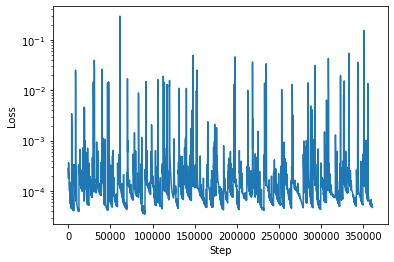

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

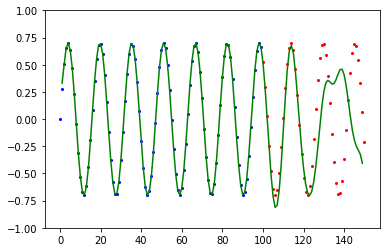

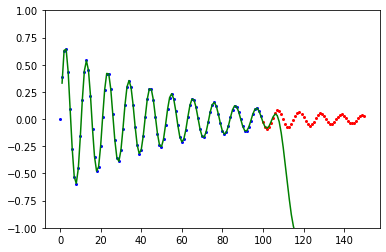

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

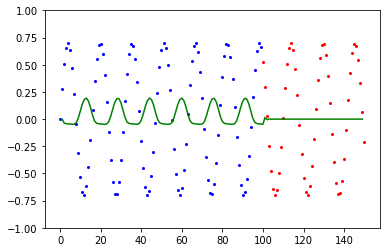

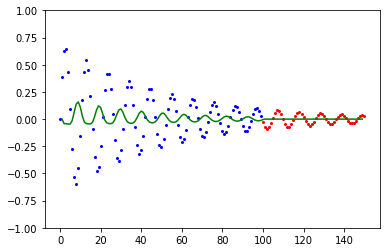

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[283200,
 Array(5.82091853e-05, dtype=float64),
 Array(0.07641826, dtype=float64),
 [(Array([[ 1.14113296, -0.46361133,  1.06696915,  0.22253509]], dtype=float64),
   Array([[-0.44122715,  0.77125737,  0.89200576,  0.08582683],
          [-0.19536973,  0.43787069,  0.44554761, -0.14512485],
          [ 0.30452818, -0.08988722,  0.71961052, -0.29909868],
          [-0.29656554, -0.45030037, -0.85597962, -0.52633305]],      dtype=float64),
   Array([ 0.01379351, -0.00215974,  0.00599593,  0.01418905], dtype=float64),
   Array([[ 0.66456312,  0.77016675,  1.09401063, -0.23777155]], dtype=float64),
   Array([[ 1.82821798,  0.25707114, -0.91671863,  0.5733584 ],
          [ 0.92573162, -2.49919509,  0.53498899, -3.97533212],
          [-3.38568049,  1.2090681 , -1.12310542, -0.87666136],
          [ 0.7673268 , -2.15044491, -1.80264972, -2.82130051]],      dtype=float64),
   Array([-1.51828186,  0.29982085, -1.3879745 ,  1.31331382], dtype=float64),
   Array([[-0.83952026,  0.54914485, -2.8

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

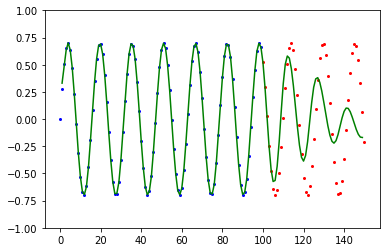

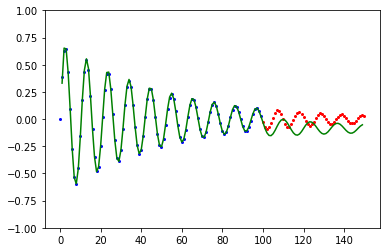

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [283200, Array(5.82091853e-05, dtype=float64), Array(0.07641826, dtype=float64)]
6900 4.1019326298260094e-05 0.18351512068611495


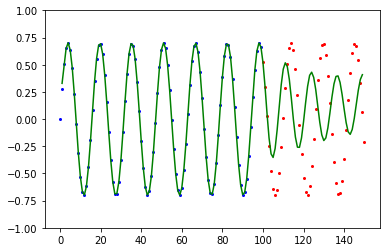

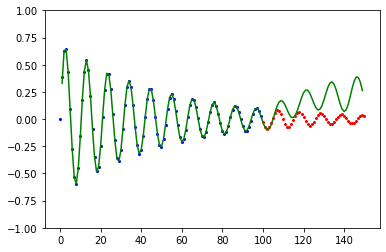

12900 3.947285146569188e-05 0.4766008409347029


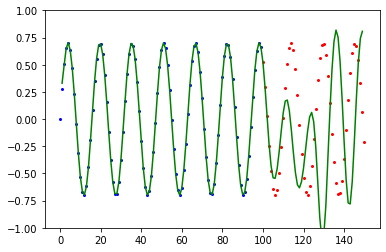

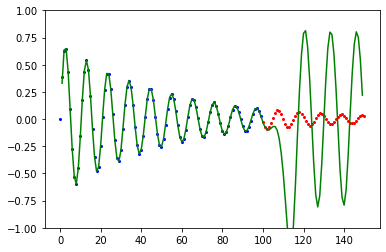

17400 9.96010154584456e-05 0.16468175934704843


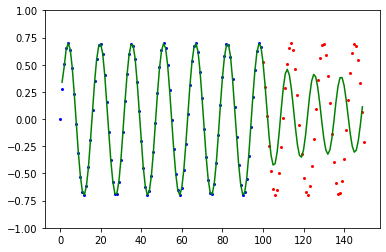

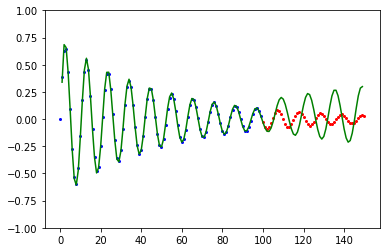

24800 5.215245645978904e-05 0.08989188261779452


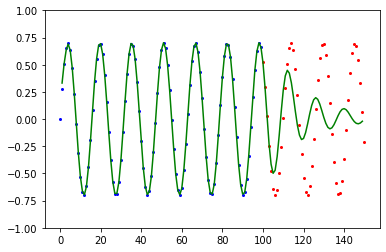

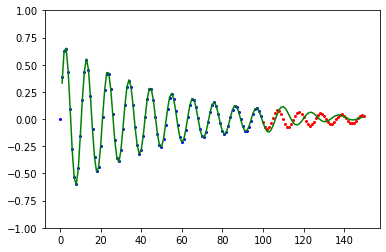

28700 7.569572836547328e-05 0.1894904320491564


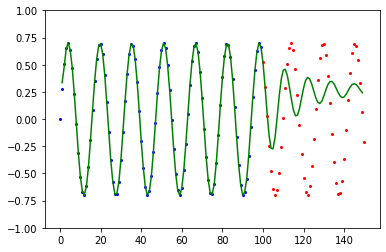

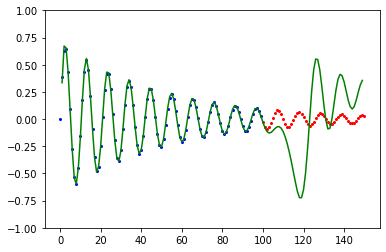

33800 9.327850512710271e-05 0.11484542797828763


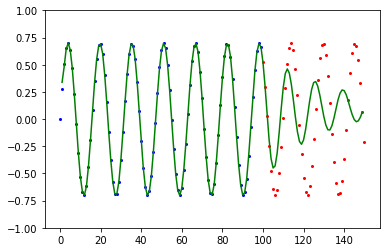

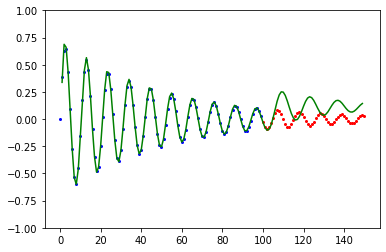

39300 8.229862377013455e-05 0.23771243703787556


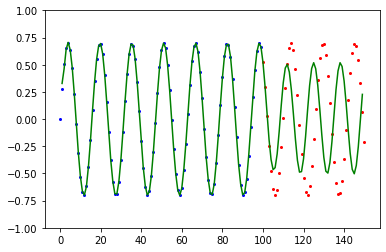

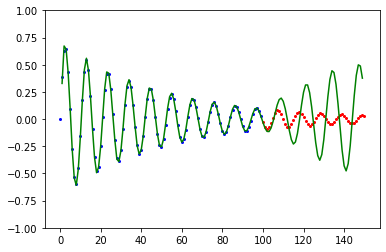

47300 4.1732182427925494e-05 0.13409714424059904


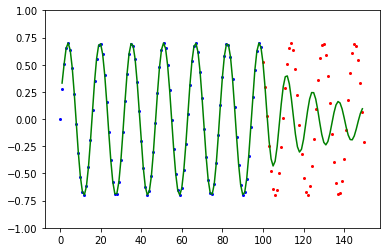

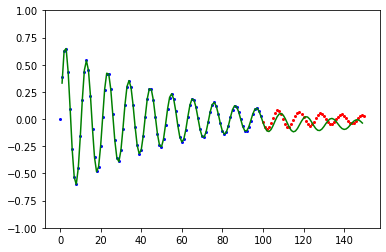

52500 4.8287494301676e-05 0.159688920768324


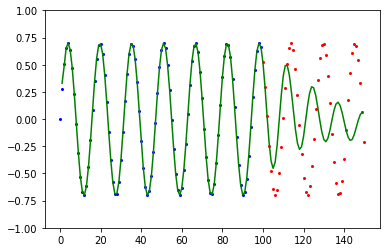

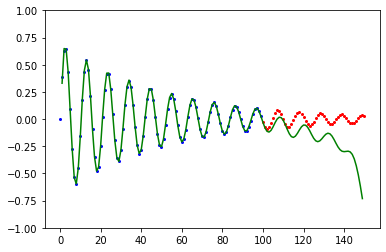

58600 4.916752808337384e-05 0.4952100561744775


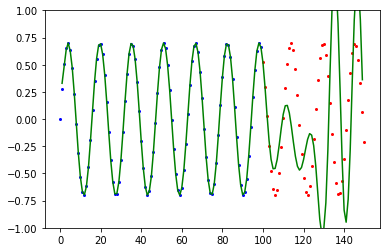

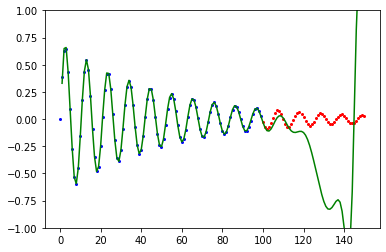

69800 4.324084951420352e-05 0.1373527212804075


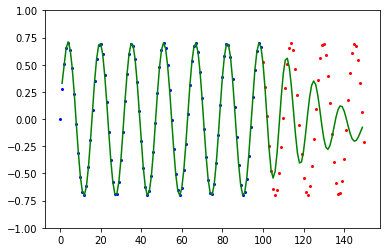

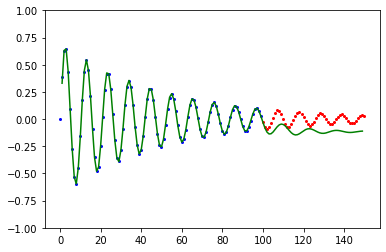

77000 6.609263722228792e-05 0.2902090594420819


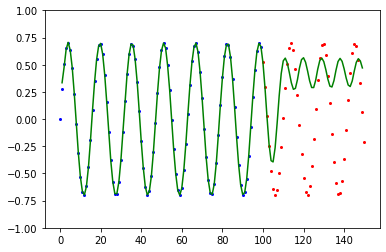

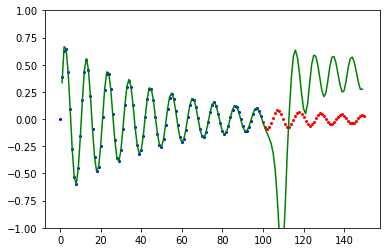

82700 7.908543466209723e-05 0.10293229132772425


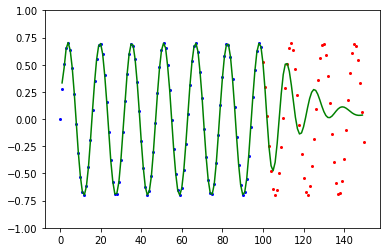

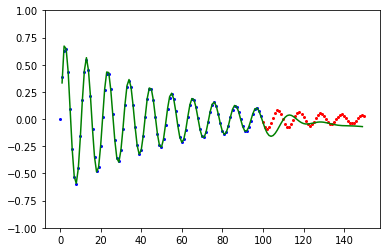

91200 3.5363916696107274e-05 6.173904587354404


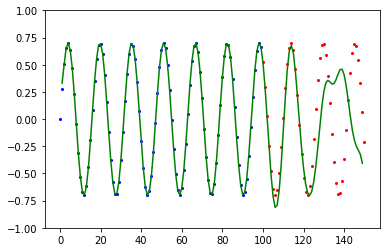

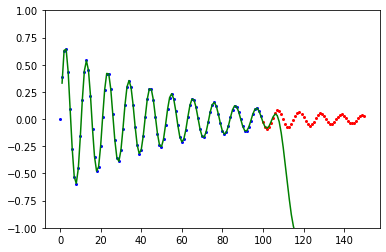

97900 8.599251260560315e-05 0.11428462050554673


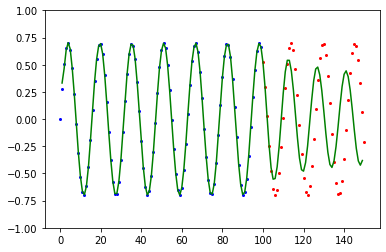

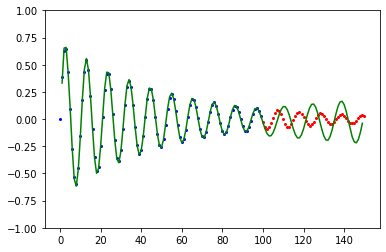

104600 5.1190836056544345e-05 0.0978489860084147


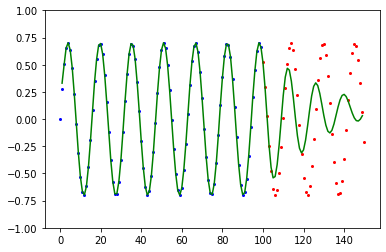

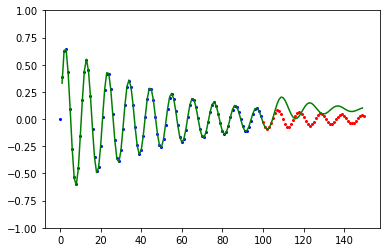

111600 4.439233840340652e-05 3.1138783813575293


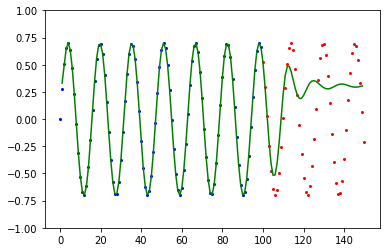

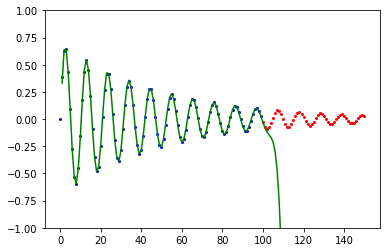

115900 9.595225357961503e-05 0.20669007755636684


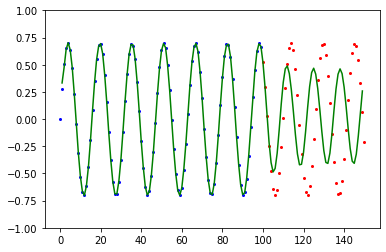

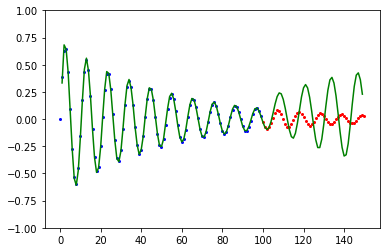

125100 7.345149071653556e-05 0.1991891245384684


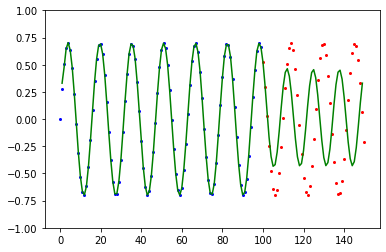

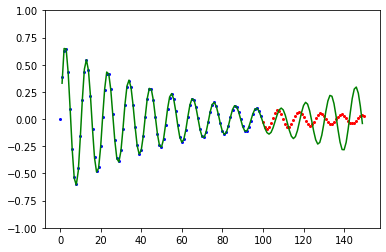

130500 4.5254231440534195e-05 3.6602983952867127


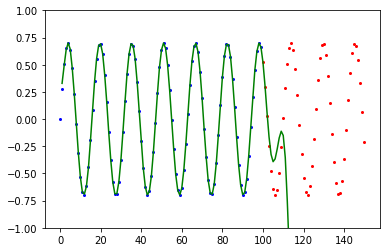

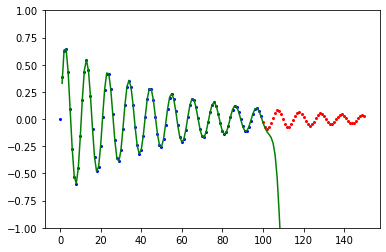

136700 6.823416942394473e-05 0.10092962330551852


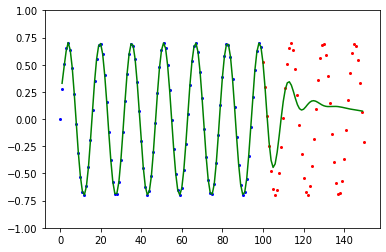

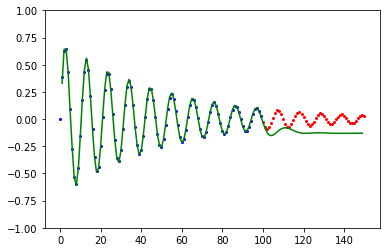

146200 6.524395712046586e-05 0.1938378553084884


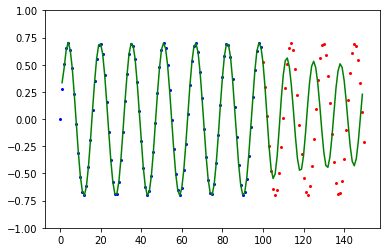

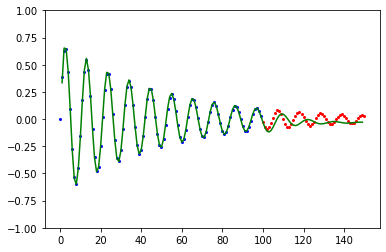

150800 0.00011727314027341701 0.1756019709314104


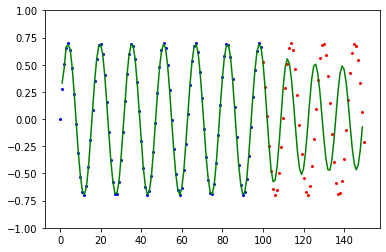

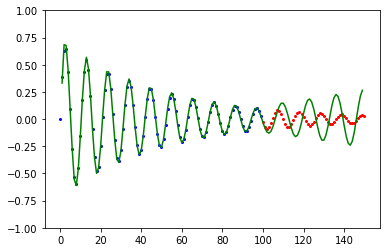

164400 4.746462629437998e-05 0.30342806988728876


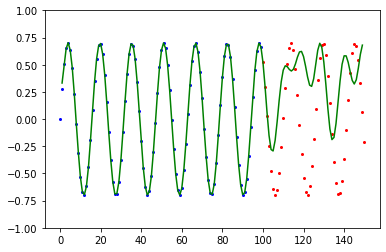

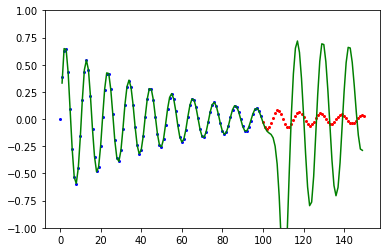

172100 4.881207005381992e-05 5.892059746073821


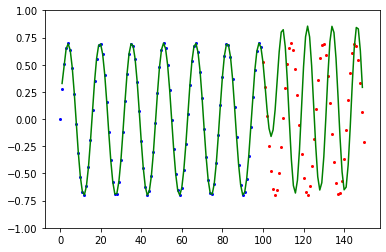

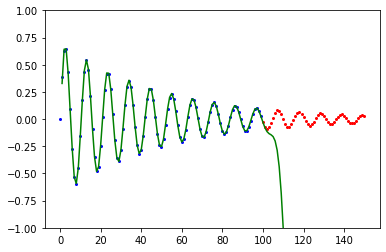

175500 8.115664296430549e-05 0.15281946982225197


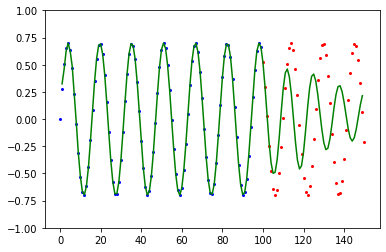

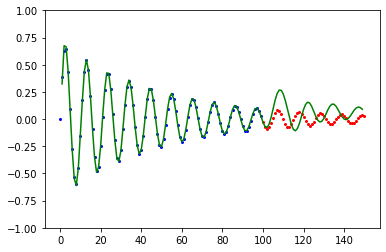

184300 4.258073444364824e-05 0.12576457632582105


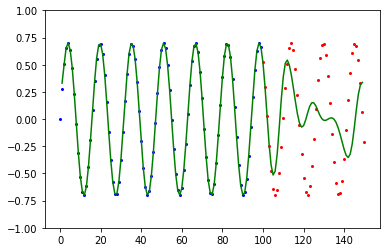

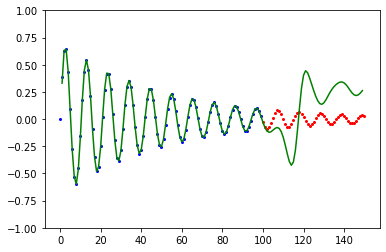

189200 5.869233679900649e-05 0.11599528320093852


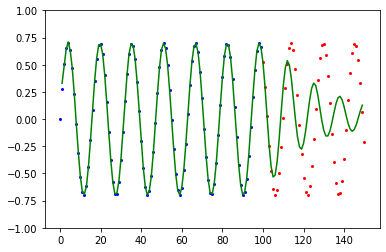

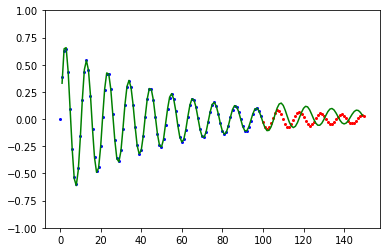

195500 7.539735798230164e-05 0.3086968116618959


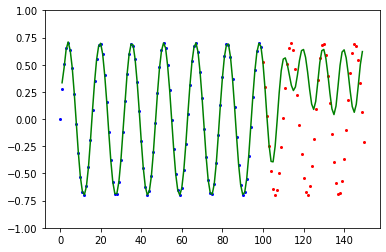

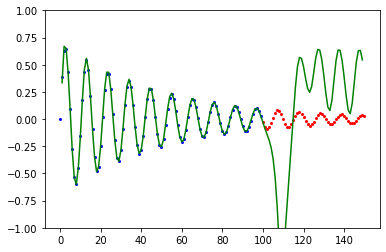

202900 4.2982069833448156e-05 0.14596118480110895


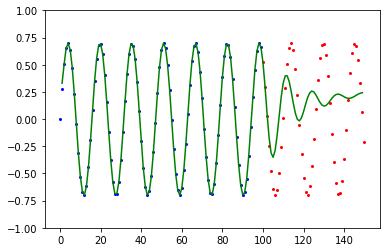

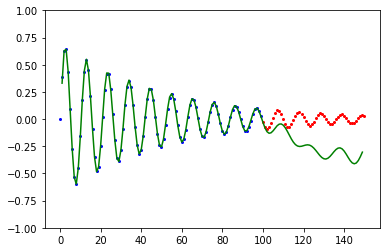

211800 6.64543158700408e-05 0.24960442190405385


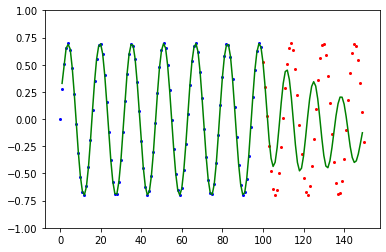

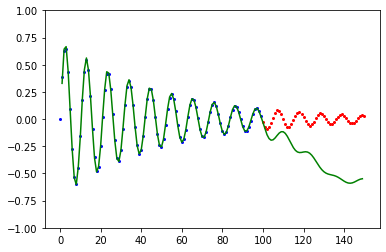

217700 7.667193327181282e-05 0.12333768236745644


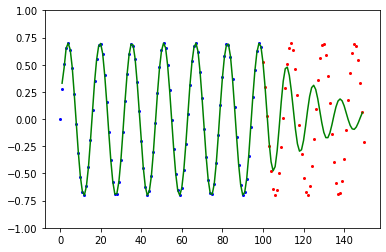

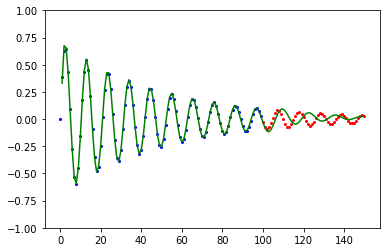

221800 7.566257722295666e-05 0.17852908380964422


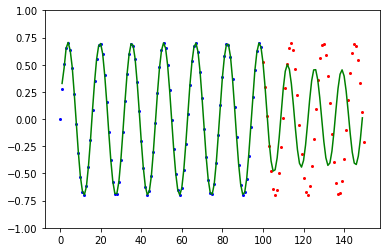

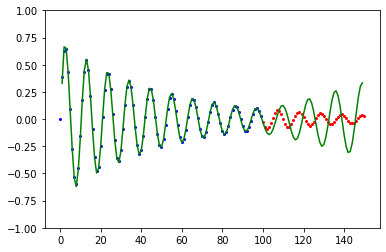

232100 4.1137962883539634e-05 0.43944017187639733


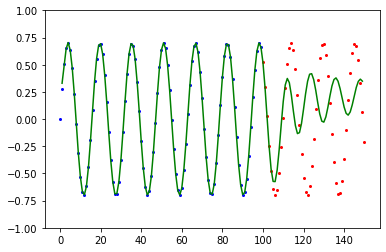

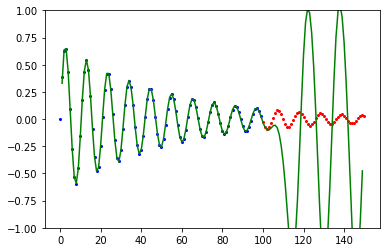

243500 5.163788818987333e-05 0.18237192699777244


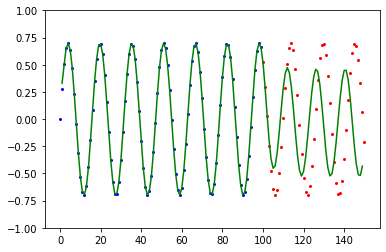

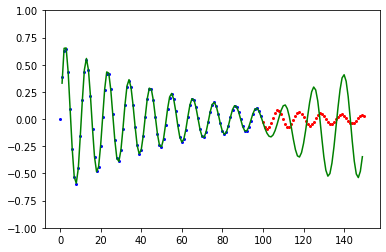

252200 5.3156251822627316e-05 4.293433507104899


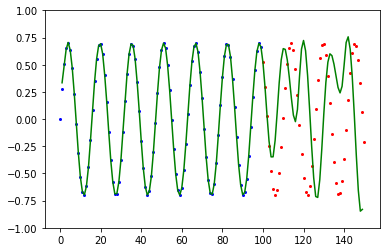

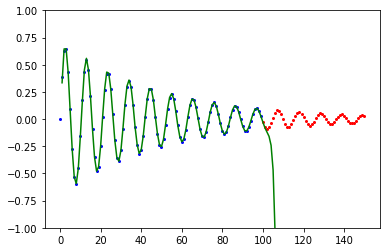

256100 4.536887488607986e-05 0.5392233374360837


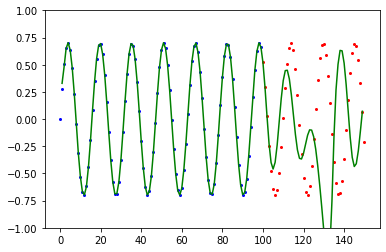

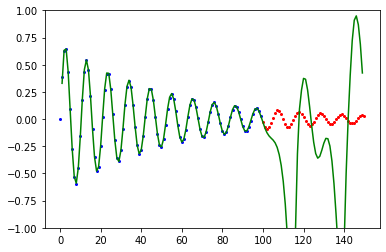

264900 4.559075621517182e-05 0.19563395711857412


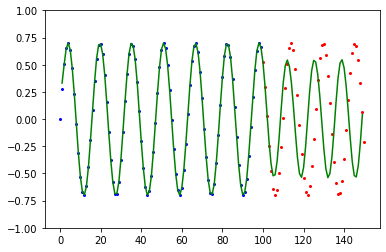

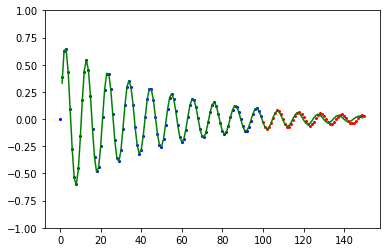

278700 4.6850187727451884e-05 1.9025059886470053


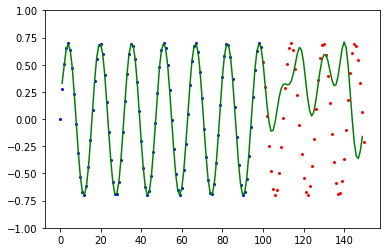

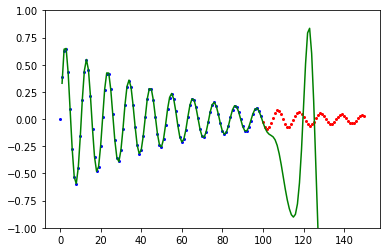

283200 5.8209185267343734e-05 0.07641826107462388


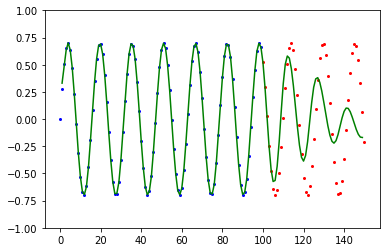

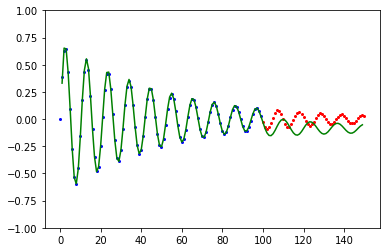

290200 4.670959324700305e-05 0.3815846805620814


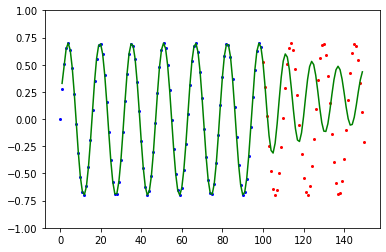

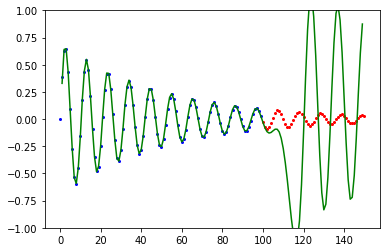

299400 4.360061674286882e-05 0.15479462713455636


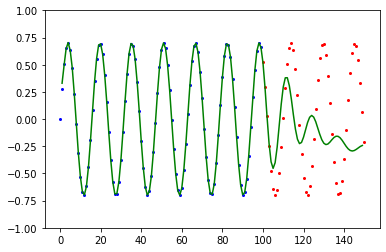

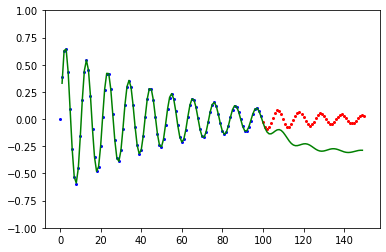

306200 5.938942575018814e-05 1.712708263202993


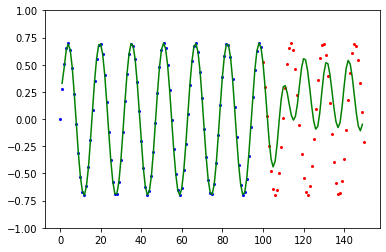

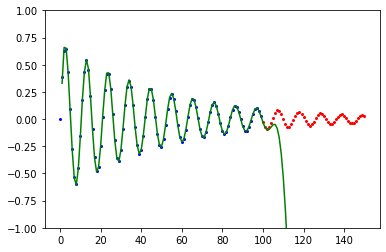

316800 7.425232612862257e-05 0.15629849147022498


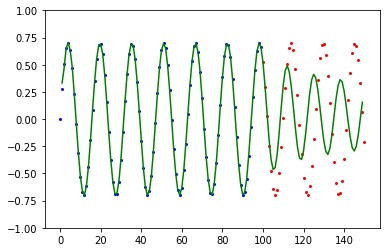

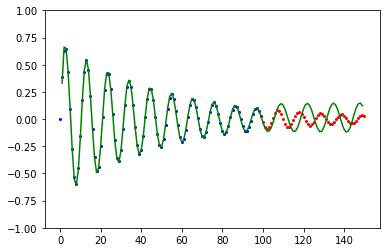

322000 5.0065325687207105e-05 0.13791922969197265


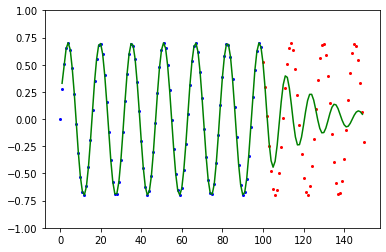

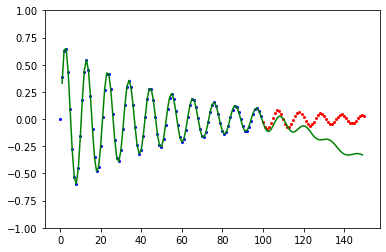

325700 6.939673227219961e-05 0.2807555410606745


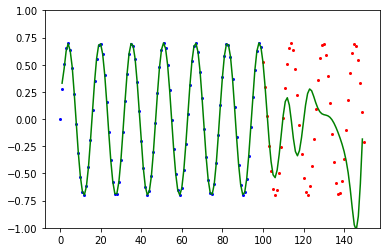

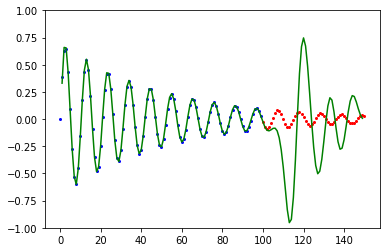

331800 9.277445670216154e-05 0.09655158978590457


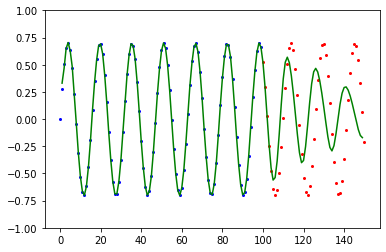

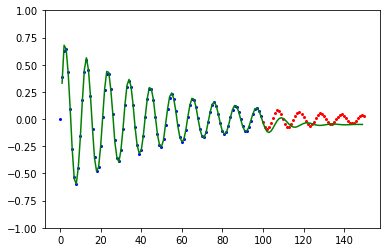

341700 5.0780472916300086e-05 0.49704989138661293


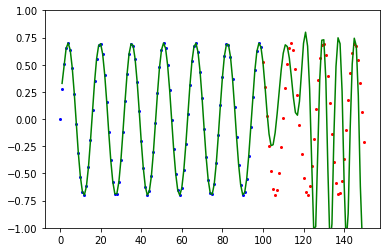

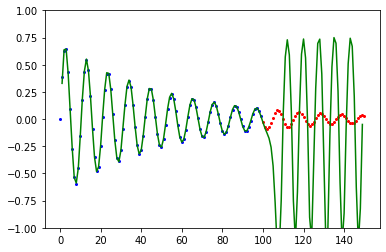

349400 5.302428615183128e-05 0.21525647797473346


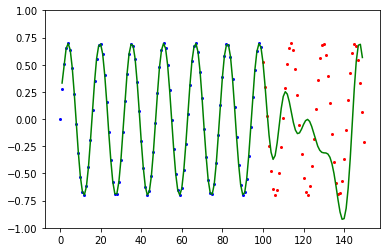

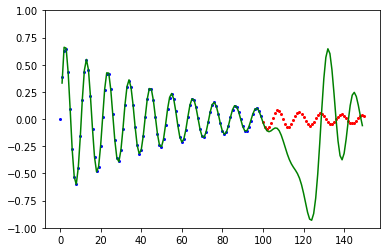

360800 4.767947631904327e-05 0.27153943462788255


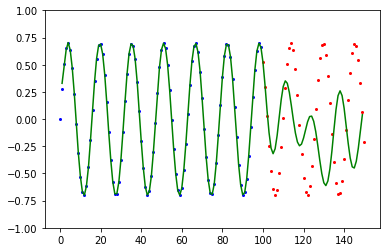

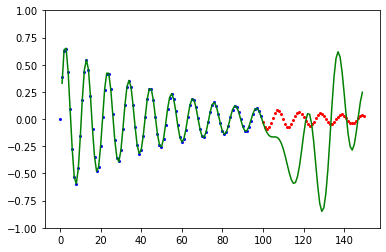

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.71884747, dtype=float64)

In [35]:
len(test_result)

50